## 7. FinBERT (Transformer-gebaseerd model voor financiële klachtomschrijvingen)

In dit notebook trainen we een **FinBERT-model** (een BERT-variant getraind op financiële teksten) om op basis van Engelstalige klachtomschrijvingen de **Nederlandse productsector** te voorspellen.
De opbouw lijkt op de eerdere notebooks (Logistic Regression, XGBoost): duidelijke stappen, aparte cellen en uitleg in het Nederlands.


### 7.1 Benodigde packages installeren (eenmalig)

Voor FinBERT gebruiken we de **Hugging Face Transformers**-bibliotheek en het **datasets**-pakket.  
Voer onderstaande cel alleen uit als je deze packages nog niet hebt geïnstalleerd in je omgeving (VS Code / venv).

In [ ]:
# Alleen de eerste keer nodig. Haal het hekje weg als je het wilt draaien.
# !pip install transformers datasets accelerate torch --upgrade

# Let op:
# - Het trainen van FinBERT is op CPU langzamer dan Logistic Regression / XGBoost.
# - Op een GPU gaat dit veel sneller. Als je geen GPU hebt, kun je onderaan de notebook
#   het aantal epochs en/of het aantal trainingsvoorbeelden verlagen.


### 7.2 Packages importeren

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

os.environ["TRANSFORMERS_NO_TORCH_DISTRIBUTED"] = "1"
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

from datasets import Dataset

from helpfuncties import (
    load_dataset,
)

c:\Users\morri\Downloads\Dataproject1 - kopie\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\morri\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Gebruik device: cuda


In [ ]:
def print_device_info():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        idx = torch.cuda.current_device()
        name = torch.cuda.get_device_name(idx)
        props = torch.cuda.get_device_properties(idx)
        vram_gb = props.total_memory / (1024**3)
        print(f"✅ Using GPU: cuda:{idx} — {name} — VRAM: {vram_gb:.1f} GB")
    else:
        device = torch.device("cpu")
        print("⚠️ Using CPU (no CUDA GPU detected)")
    return device

device = print_device_info()

✅ Using GPU: cuda:0 — NVIDIA GeForce RTX 5070 Laptop GPU — VRAM: 8.0 GB


### 7.3 Dataset inladen

In [ ]:
# Laad de klachten-dataset via de helperfunctie uit preprocessing.py
df = load_dataset()  # verwijdert duplicates in klachtomschrijvingen

print("Vorm van de dataset:", df.shape)
print("Kolommen:", df.columns.tolist())

# In deze dataset:
# - 'Omschrijving' bevat Engelstalige klachtomschrijvingen
# - 'Product' bevat de Nederlandse productsector (doelklasse)

# Zorg dat tekst altijd string is
df["Omschrijving"] = df["Omschrijving"].astype(str)

df[["Omschrijving", "Product"]].head()

Vorm van de dataset: (14816, 2)
Kolommen: ['Product', 'Omschrijving']


,Omschrijving,Product
0,ON XX/XX/2016 I had a deposit of XXXX into my ...,Bankrekening
1,Chase Bank accepted a {$3500.00} check for dep...,Bankrekening
2,I tried to open an account with Bank of Americ...,Bankrekening
3,On XXXX my account was gotten into on USAA by ...,Bankrekening
4,I have been deprived of my income as Bank of A...,Bankrekening


#### 7.3.1 Labels encoden (Product → numerieke klassen)

In [ ]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Product"])

num_labels = len(label_encoder.classes_)
print("Aantal klassen:", num_labels)
print("Mapping (label → product):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")

Aantal klassen: 6
Mapping (label → product):
0 -> Bankrekening
1 -> Consumentenkrediet
2 -> Creditcard
3 -> Hypotheek
4 -> Incasso
5 -> Kredietregistratie


### 7.4 Train / Validatie / Test split

In [ ]:
X = df["Omschrijving"].values
y = df["label"].values

# Eerst train + (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.35,
    random_state=42,
    stratify=y
)

# Daarna splitsen we X_temp in validatie en test (elk 15% van totaal)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.57,
    random_state=42,
    stratify=y_temp
)

print("Train samples:", len(X_train))
print("Validatie samples:", len(X_val))
print("Test samples:", len(X_test))

Train samples: 9630
Validatie samples: 2229
Test samples: 2957


#### 7.4.1 Optionele subsampling (voor snellere training op CPU)

Als FinBERT-training op jouw laptop te lang duurt, kun je het aantal trainingsvoorbeelden beperken.
Pas `MAX_TRAIN_SAMPLES` aan naar een kleiner getal (of zet op `None` om alles te gebruiken).

In [ ]:
MAX_TRAIN_SAMPLES = None  # bijv. 8000 voor snellere runs; None = gebruik alle training data

if MAX_TRAIN_SAMPLES is not None and MAX_TRAIN_SAMPLES < len(X_train):
    X_train_sub = X_train[:MAX_TRAIN_SAMPLES]
    y_train_sub = y_train[:MAX_TRAIN_SAMPLES]
    print(f"Gebruik alleen de eerste {MAX_TRAIN_SAMPLES} trainingsvoorbeelden.")
else:
    X_train_sub = X_train
    y_train_sub = y_train

print("Effectief aantal trainingsvoorbeelden:", len(X_train_sub))

Effectief aantal trainingsvoorbeelden: 9630


### 7.5 FinBERT tokenizer en Hugging Face Datasets maken

In [ ]:
MODEL_NAME = "ProsusAI/finbert"  # FinBERT-model getraind op financiële Engels

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

max_length = 512  # maximale sequence-lengte (kan hoger, maar is trager)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

# Bouw Hugging Face Dataset-objecten
train_dataset = Dataset.from_dict({"text": X_train_sub.tolist(), "label": y_train_sub.tolist()})
val_dataset   = Dataset.from_dict({"text": X_val.tolist(),        "label": y_val.tolist()})
test_dataset  = Dataset.from_dict({"text": X_test.tolist(),       "label": y_test.tolist()})

# Tokenizen
train_dataset = train_dataset.map(tokenize_batch, batched=True)
val_dataset   = val_dataset.map(tokenize_batch, batched=True)
test_dataset  = test_dataset.map(tokenize_batch, batched=True)

# Set format zodat Trainer er direct mee kan werken
train_dataset = train_dataset.remove_columns(["text"])
val_dataset   = val_dataset.remove_columns(["text"])
test_dataset  = test_dataset.remove_columns(["text"])

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")
test_dataset.set_format(type="torch")

Map: 100%|██████████| 2957/2957 [00:00<00:00, 6366.78 examples/s]


In [ ]:
import transformers
print(transformers.__version__)

4.57.3


### 7.6 FinBERT model en trainingsinstellingen

In [ ]:
set_seed(42)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

model.to(device)

# Trainingsconfiguratie
EPOCHS = 3          # verhoog naar 3 als je meer nauwkeurigheid wilt en de tijd het toelaat
BATCH_SIZE = 16     # 8 is veilig voor CPU; met GPU kun je naar 16 of 32
LR = 2e-5           # standaard kleine learning rate voor BERT-finetuning

output_dir = "./finbert_product_classifier_products"

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="steps",
    save_strategy="steps",
    logging_steps=50,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=1,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_precision",
    greater_is_better=True,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### 7.6.1 Metrics-functie (accuracy, macro precision, macro recall, macro F1)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

#### 7.6.2 Trainer-object aanmaken

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer

C:\Users\morri\AppData\Local\Temp\ipykernel_7664\4142038620.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### 7.7 Finetuning van FinBERT op klachtomschrijvingen

In [ ]:
train_result = trainer.train()
trainer.save_model(output_dir)

print("Train metrics:", train_result.metrics)

eval_metrics = trainer.evaluate(eval_dataset=val_dataset)
print("\nBeste model evaluatiemetrics (validatieset):")
for k, v in eval_metrics.items():
    if isinstance(v, (float, int)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
50,1.729500,1.606212,0.349484,0.119717,0.246927,0.161254
100,1.499400,1.282330,0.561687,0.287833,0.399021,0.334046
150,1.099400,0.848192,0.754150,0.787710,0.661807,0.669727
200,0.778400,0.676764,0.795873,0.784760,0.748035,0.761413
250,0.631700,0.587155,0.824585,0.806631,0.781369,0.791562
300,0.640000,0.545049,0.831314,0.810958,0.798960,0.803982
350,0.524300,0.551211,0.830866,0.823214,0.791162,0.803181
400,0.473300,0.531682,0.835801,0.840999,0.791760,0.809425
450,0.527600,0.494455,0.843428,0.840966,0.806823,0.816758
500,0.526400,0.455517,0.851054,0.835894,0.823517,0.828159


Train metrics: {'train_runtime': 2388.8739, 'train_samples_per_second': 12.094, 'train_steps_per_second': 0.756, 'total_flos': 7601551384596480.0, 'train_loss': 0.458938815400978, 'epoch': 3.0}



Beste model evaluatiemetrics (validatieset):
eval_loss: 0.4369
eval_accuracy: 0.8681
eval_macro_precision: 0.8641
eval_macro_recall: 0.8318
eval_macro_f1: 0.8443
eval_runtime: 33.0118
eval_samples_per_second: 67.5210
eval_steps_per_second: 4.2410
epoch: 3.0000


### 7.8 Evaluatie op de testset

#### 7.8.1 Voorspellingen 

In [ ]:
test_predictions = trainer.predict(test_dataset)
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids

y_pred_finbert = np.argmax(test_logits, axis=-1)
y_true_finbert = test_labels

Accuracy FinBERT: 0.877
Macro precision FinBERT: 0.876
Macro recall FinBERT: 0.839
Macro F1 FinBERT: 0.853


#### 7.8.2 Classification report per productsector

In [ ]:
y_true_names = label_encoder.inverse_transform(y_true_finbert)
y_pred_names = label_encoder.inverse_transform(y_pred_finbert)

print('\nClassification Report FinBERT:\n')
print(classification_report(y_true_names, y_pred_names))

                    precision    recall  f1-score   support

      Bankrekening       0.86      0.86      0.86       297
Consumentenkrediet       0.88      0.61      0.72       189
        Creditcard       0.85      0.84      0.84       375
         Hypotheek       0.93      0.95      0.94       661
           Incasso       0.83      0.91      0.87       813
Kredietregistratie       0.92      0.87      0.90       622

          accuracy                           0.88      2957
         macro avg       0.88      0.84      0.85      2957
      weighted avg       0.88      0.88      0.88      2957



#### 7.8.3 Confusion matrix

[[254   3  20   8   8   4]
 [  4 115  10  13  44   3]
 [ 22   2 315   4  26   6]
 [  6   1   6 629  11   8]
 [  8   8  19  16 736  26]
 [  3   2   2   8  63 544]]


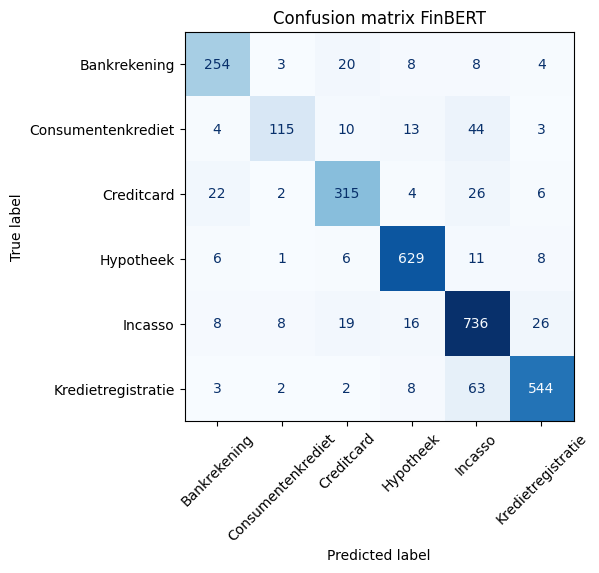

In [ ]:
cm = confusion_matrix(y_true_names, y_pred_names, labels=label_encoder.classes_)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax, colorbar=False)
plt.title('Confusion matrix FinBERT')
plt.tight_layout()
plt.savefig("afbeeldingen/confusion_matrix_FinBERT.png", dpi=300, bbox_inches='tight') 
plt.show()

### 7.9 Model en label-encoder opslaan

In [ ]:
# Sla de label-encoder op zodat je later voorspellingen weer naar productnamen kunt terugvertalen
import joblib

os.makedirs(output_dir, exist_ok=True)
label_path = os.path.join(output_dir, "label_encoder.joblib")
joblib.dump(label_encoder, label_path)

print(f"LabelEncoder opgeslagen naar: {label_path}")

LabelEncoder opgeslagen naar: ./finbert_product_classifier_products\label_encoder.joblib


### 7.10 Conclusie modelprestatie
Het FinBERT-model haalt een weighted precision van 0,88 en presteert daarmee het beste van alle geteste modellen. Hypotheek (0,93) en Kredietregistratie (0,92) halen de minimale eis van 90% precision. De overige productsectoren blijven hier net onder, met Consumentenkrediet als laagst scorende klasse (0,88).

Vergeleken met Logistic Regression, Naive Bayes, SGDClassifier en Random Forest laat FinBERT duidelijk betere resultaten zien. Ondanks de verbetering wordt de eis van 90% precision voor alle subklassen nog steeds net niet volledig gehaaald. 